# VISUALIZE VALUE FUNCTIONS

In [ ]:
%load_ext autoreload
%autoreload 2

import torch 
import random
import numpy as np 
from matplotlib import pyplot as plt

import sys 
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator")
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators")

from safe_neural_operators.data_collection import load_hjr_solution, \
    get_dynamics_model_given_disturbance_fn, \
    get_disturbance_function_sincos
from safe_neural_operators.hjr_dataset import load_full_training_dataset, HJR_SubDataset, HJRDataset

sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project")

from deepreach.dynamics import dynamics 
from deepreach.dynamics import dynamics_hjr
from deepreach.utils.comparisons import GroundTruthHJSolution

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
load_path = "/media/jingpei/DATA/fno_gp_data"
load_index = 20 

loaded_input, loaded_output = load_hjr_solution(
    load_path=load_path,  
    load_index=load_index
)

print("loaded_input shape", loaded_input.shape)
print("loaded_output shape", loaded_output.shape)

loaded_input shape torch.Size([41, 41, 4])
loaded_output shape torch.Size([41, 41, 41, 41])


/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/data_collection.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  input_tensor = torch.load(input_pat

Text(0.5, 1.0, 'Input')

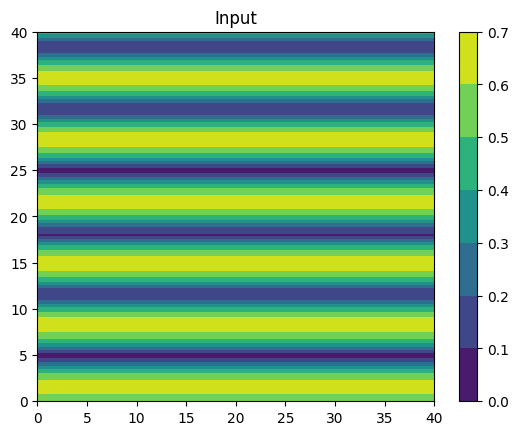

In [52]:
plt.figure()
plt.contourf(loaded_input.numpy()[:, :, 0], cmap='viridis')  # Use 'viridis' colormap
plt.colorbar()
plt.title("Input")

In [53]:
# Load dataset - just to create the data processor 
# Dataset Parameters 
data_root_dir = load_path 
samples_for_train = 50#400 #500
samples_for_test = 50 
datapoints_per_sample = 1000
batch_size = 256 #32
pre_sample_dataset = True 
encode_output = False 
encode_input = True 
encoding = "channel-wise"
full_ordered_dataset = False

dataset = HJRDataset(root_dir=data_root_dir, 
                    samples_for_train=samples_for_train, 
                    samples_for_test=samples_for_test, 
                    datapoints_per_sample=datapoints_per_sample,

                    batch_size=batch_size, 
                    pre_sample_dataset=pre_sample_dataset, 

                    encode_output=encode_output,
                    encode_input=encode_input,
                    encoding=encoding, 
                    full_ordered_dataset=full_ordered_dataset)

data_processor = dataset.data_processor
grid_states = dataset.grid_states

/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/data_collection.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  grid_states = torch.load(grid_state

In [54]:
xvels = grid_states[0, 0, :, 0, 2]
yvels = grid_states[0, 0, 0, :, 3]
print("xvels", xvels)
print("yvels", yvels)

xvels [-2.         -1.9000001  -1.8        -1.7        -1.5999999  -1.5
 -1.4000001  -1.3        -1.2        -1.0999999  -1.         -0.90000004
 -0.79999995 -0.69999987 -0.59999996 -0.5        -0.40000004 -0.29999995
 -0.19999987 -0.09999996  0.          0.10000014  0.20000005  0.29999995
  0.4000001   0.5         0.60000014  0.70000005  0.79999995  0.9000001
  1.          1.1000001   1.2         1.3         1.4000001   1.5
  1.6000001   1.7         1.8         1.9000001   2.        ]
yvels [-2.         -1.9000001  -1.8        -1.7        -1.5999999  -1.5
 -1.4000001  -1.3        -1.2        -1.0999999  -1.         -0.90000004
 -0.79999995 -0.69999987 -0.59999996 -0.5        -0.40000004 -0.29999995
 -0.19999987 -0.09999996  0.          0.10000014  0.20000005  0.29999995
  0.4000001   0.5         0.60000014  0.70000005  0.79999995  0.9000001
  1.          1.1000001   1.2         1.3         1.4000001   1.5
  1.6000001   1.7         1.8         1.9000001   2.        ]


xvel:  0.0
yvel:  0.0


Text(0, 0.5, 'y')

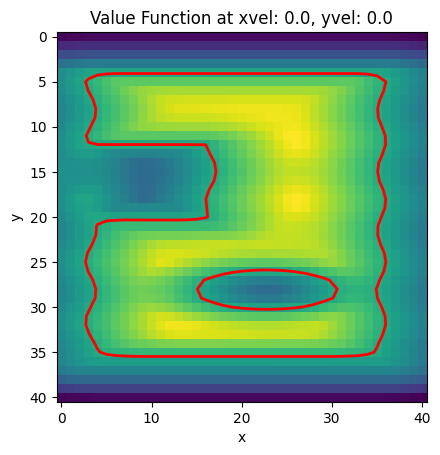

In [55]:
xvel_slice = 20 
yvel_slice = 20
xvel = xvels[xvel_slice]
yvel = yvels[yvel_slice]
print("xvel: ", xvel)
print("yvel: ", yvel)

curr_value_function = loaded_output[:, :, xvel_slice, yvel_slice]

plt.figure()
plt.imshow(curr_value_function)
plt.contour(curr_value_function, levels=[0], colors='red', linewidths=2)
plt.title(f"Value Function at xvel: {xvel}, yvel: {yvel}")
plt.xlabel("x")
plt.ylabel("y")

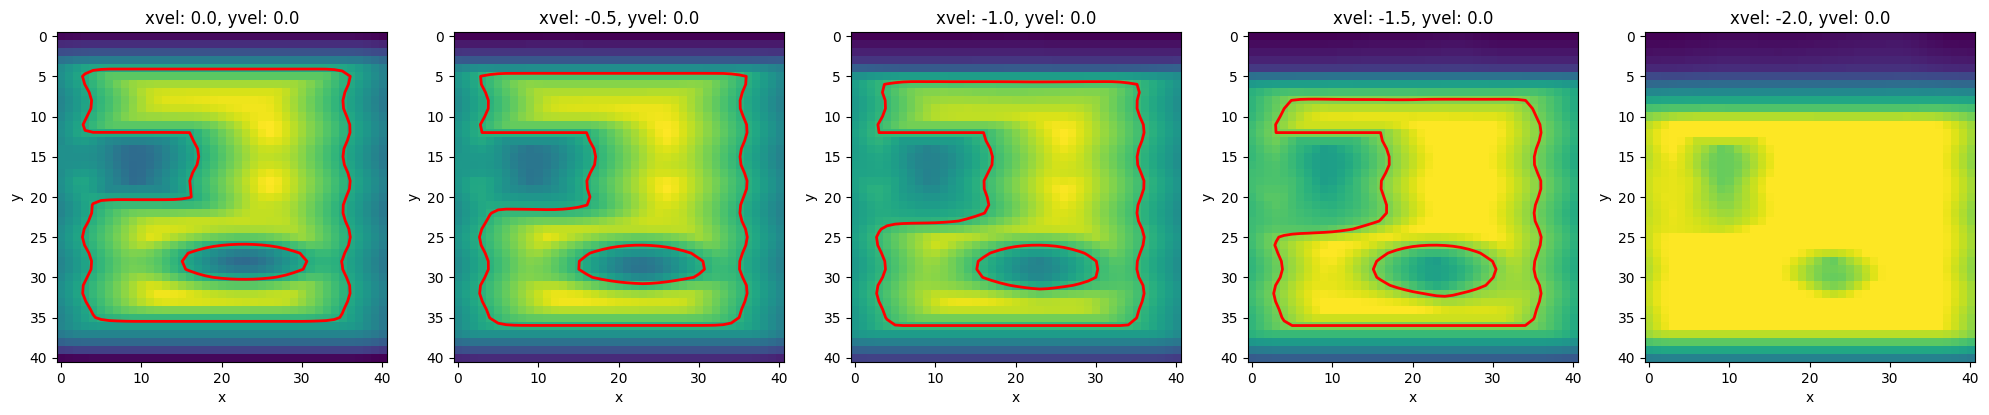

In [56]:
xvel_slices = [20, 15, 10, 5, 0]
yvel_slice = 20 
fig, axes = plt.subplots(1, len(xvel_slices), figsize=(20, 5))

for i, xvel_slice in enumerate(xvel_slices):
    xvel = xvels[xvel_slice]
    yvel = yvels[yvel_slice]
    curr_value_function = loaded_output[:, :, xvel_slice, yvel_slice]

    axes[i].imshow(curr_value_function)
    axes[i].contour(curr_value_function, levels=[0], colors='red', linewidths=2)
    axes[i].set_title(f"xvel: {xvel}, yvel: {yvel}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()

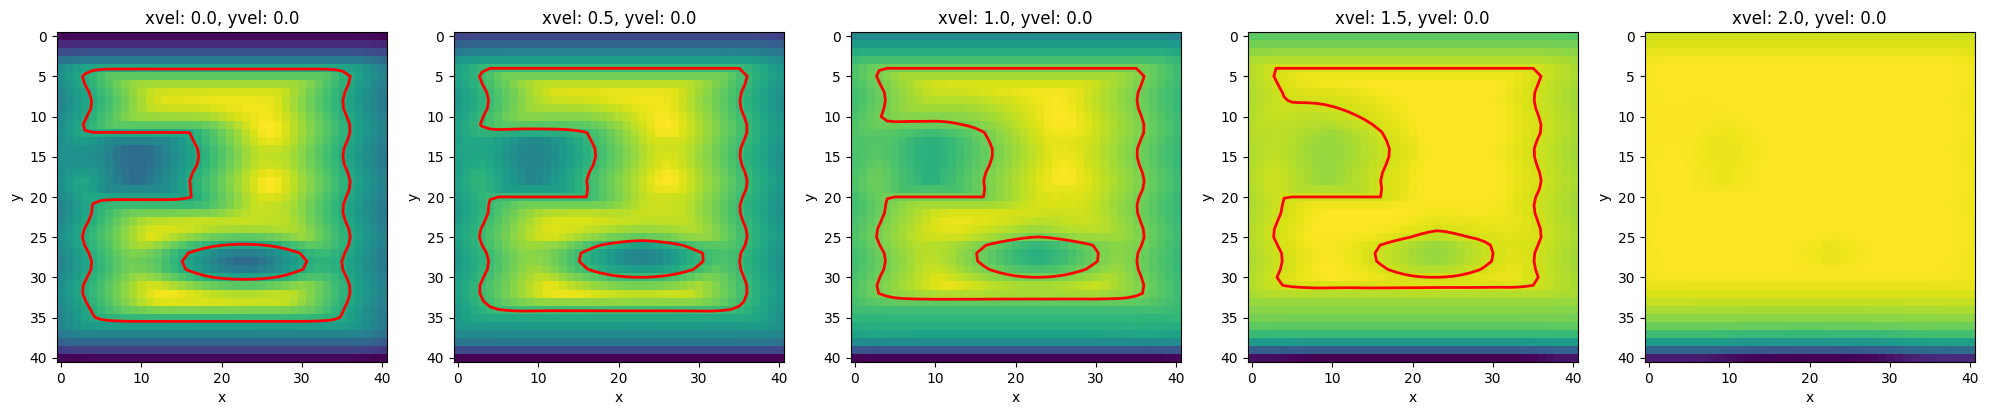

In [57]:
xvel_slices = [20, 25, 30, 35, 40]
yvel_slice = 20 
fig, axes = plt.subplots(1, len(xvel_slices), figsize=(20, 5))

for i, xvel_slice in enumerate(xvel_slices):
    xvel = xvels[xvel_slice]
    yvel = yvels[yvel_slice]
    curr_value_function = loaded_output[:, :, xvel_slice, yvel_slice]

    axes[i].imshow(curr_value_function)
    axes[i].contour(curr_value_function, levels=[0], colors='red', linewidths=2)
    axes[i].set_title(f"xvel: {xvel}, yvel: {yvel}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()

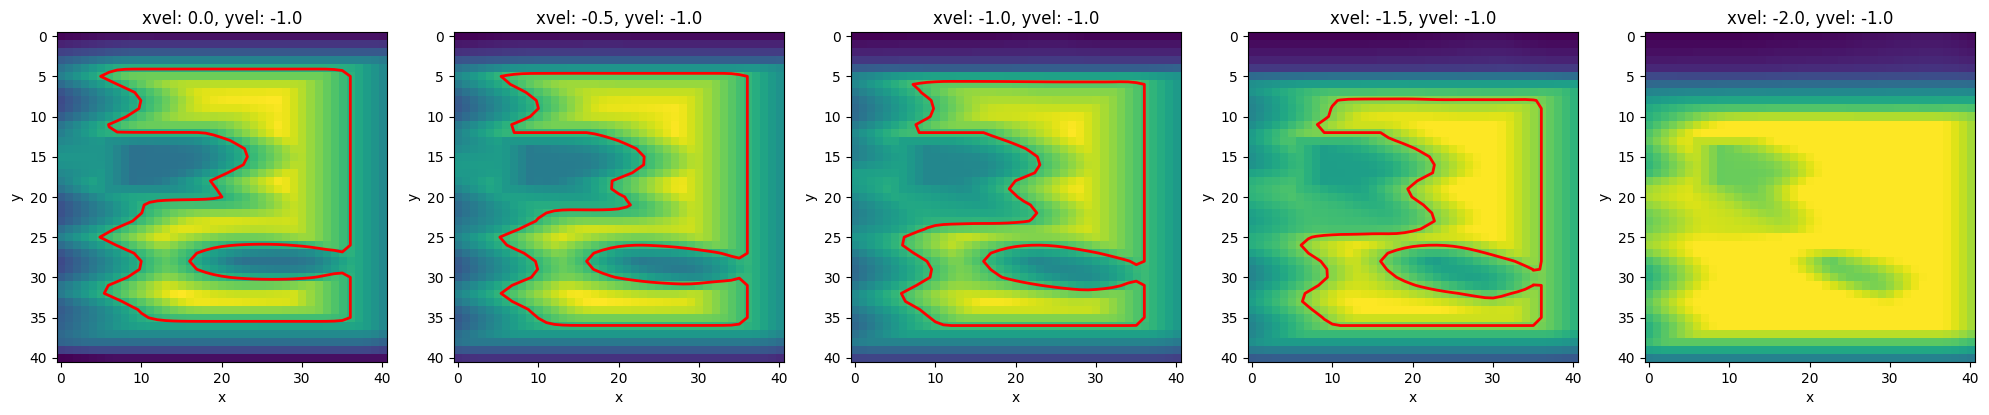

In [58]:
xvel_slices = [20, 15, 10, 5, 0]
yvel_slices = [10] * 5
fig, axes = plt.subplots(1, len(xvel_slices), figsize=(20, 5))

for i, xvel_slice in enumerate(xvel_slices):
    yvel_slice = yvel_slices[i]
    xvel = xvels[xvel_slice]
    yvel = yvels[yvel_slice]
    curr_value_function = loaded_output[:, :, xvel_slice, yvel_slice]

    axes[i].imshow(curr_value_function)
    axes[i].contour(curr_value_function, levels=[0], colors='red', linewidths=2)
    axes[i].set_title(f"xvel: {xvel}, yvel: {yvel}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()